# SkillBridge — Module 1: Data Audit & EDA
### KPITB × UETM — AI/ML Career Recommendation, Job Matching & Skill-Gap Analysis System

## 1. Introduction

**What is SkillBridge?**

SkillBridge is an AI/ML system that helps university students in Pakistan understand which career field
suits them based on their skills and academic profile, and then connects that recommendation to real
job opportunities in the Pakistani job market.

**Why do we have two datasets?**

- **Dataset 1 (Student Skills & Career Dataset)** describes students: their academics, soft skills,
  40+ technical skills, and the career field they are best suited for (`Career_Field`). This will later
  be used to train a **career recommendation model**.
- **Dataset 2 (Pakistan Job Market Dataset)** describes real job postings in Pakistan: job title,
  company, city, sector, salary, required skills, experience, and education. This will later be used to
  **match a recommended career to actual jobs** and highlight **skill gaps**.

**Why is data auditing necessary?**

Before we build any machine learning model, we must understand the data we are working with:
- Is the data clean, or are there missing values, duplicates, or wrong values?
- Are the categories (like `Career_Field` and `Job Title`) consistent and well defined?
- Can Dataset 1 and Dataset 2 actually be connected to each other?

Skipping this step often leads to models that fail silently, produce biased results, or cannot be
connected to the rest of the system.

**What we will NOT do in this module**

- We will **not** train any machine learning model.
- We will **not** permanently clean, remove, or modify the datasets.
- We will only **observe, measure, and report** — cleaning and feature engineering are the job of
  **Module 2**.


## 2. Import Libraries

We import the core libraries needed to load, inspect, analyze, and visualize the datasets:

- **pandas** — loading and manipulating tabular data
- **numpy** — numerical operations
- **matplotlib / seaborn** — visualizations
- **re** — light text pattern inspection (used only for exploratory comparison, not cleaning)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 100)

print("Libraries imported successfully.")


: 

## 3. Locate and Load Dataset 1

We first check which files are available in our working directory, then load Dataset 1.

`head()` shows us the first 5 rows so we can visually confirm the data loaded correctly, and `shape`
tells us the number of rows and columns.


In [2]:
print("Files in working directory:")
for f in os.listdir("."):
    if f.endswith((".csv", ".xlsx", ".xls")):
        print(" -", f)


Files in working directory:
 - skillbridge_synthetic_student_skills.csv
 - pakistan_job_market_dataset.csv


In [ ]:
DATASET_1_PATH = "D:\Skill\skillbridge_synthetic_student_skills.csv"

df1 = pd.read_csv(DATASET_1_PATH)
df1.head()


,Student_ID,Age,Gender,University_Year,Major,CGPA,Attendance_Percentage,Study_Hours_Per_Week,Projects_Completed,Certifications_Count,Internships,Communication_Skills,Teamwork,Problem_Solving,Interest_Domain,Skill_AWS,Skill_Adobe_XD,Skill_Agile,Skill_Ansible,Skill_Azure,Skill_CI_CD,Skill_Cybersecurity,Skill_Data_Analysis,Skill_Django,Skill_Docker,Skill_Elasticsearch,Skill_FastAPI,Skill_Figma,Skill_Flutter,Skill_GCP,Skill_Git,Skill_GraphQL,Skill_JavaScript,Skill_Kubernetes,Skill_Laravel,Skill_Linux,Skill_Machine_Learning,Skill_MongoDB,Skill_MySQL,Skill_Networking,Skill_Node.js,Skill_NumPy,Skill_PHP,Skill_Pandas,Skill_PostgreSQL,Skill_PyTorch,Skill_Python,Skill_REST_APIs,Skill_React,Skill_React_Native,Skill_Redis,Skill_SQL,Skill_Scrum,Skill_TensorFlow,Skill_Terraform,Skill_TypeScript,Career_Field
0,SS00001,21,Male,Junior,Artificial Intelligence,2.74,93,24,11,0,0,10,3,4,Business & Analytics,1,3,3,5,0,2,0,6,3,0,2,1,2,1,1,2,2,0,2,2,4,2,1,10,0,4,8,0,9,7,1,0,3,0,0,1,6,2,1,4,3,Data Analyst
1,SS00002,18,Male,Freshman,Electrical Engineering,3.22,84,20,5,2,2,6,6,3,Data & AI,4,4,0,1,2,4,1,1,0,5,3,5,2,4,3,1,3,5,2,5,0,8,2,1,2,0,6,3,9,1,5,6,4,2,1,3,2,4,6,1,1,AI Engineer
2,SS00003,21,Male,Senior,Electrical Engineering,2.86,73,24,14,1,2,7,6,6,Software Development,1,2,9,0,2,6,6,0,0,2,0,0,2,5,2,7,3,8,2,0,3,3,0,0,4,3,0,1,2,3,4,7,9,4,2,0,5,3,0,2,8,Software Engineer
3,SS00004,21,Male,Senior,Software Engineering,3.11,90,28,9,1,1,7,8,4,Data & AI,3,4,0,2,0,0,4,1,4,8,7,2,0,2,0,4,2,2,2,3,1,8,4,1,0,1,8,2,8,5,7,5,4,2,4,4,0,5,8,1,2,Machine Learning Engineer
4,SS00005,23,Female,Freshman,Software Engineering,3.34,92,13,10,0,1,7,4,9,Web Development,3,0,4,1,4,1,1,0,0,3,0,0,0,3,5,6,0,6,2,3,6,2,9,1,2,6,0,1,1,1,1,4,10,6,1,3,10,2,4,5,7,Full Stack Developer


In [4]:
df1.shape


(6000, 57)

**What does this result mean?**

`df1.shape` returns `(rows, columns)`. This tells us how many student records we have and how many
attributes (columns) describe each student, before we do any cleaning.


## 4. Dataset 1 — Basic Information

**What are we doing?**

We inspect the structure of Dataset 1: its columns, data types, and statistical summary. This tells us
what kind of data we are dealing with before diving into deeper analysis.

### 4.1–4.2 Rows, Columns, and Column Names


In [5]:
print(f"Rows: {df1.shape[0]}")
print(f"Columns: {df1.shape[1]}")
print()
print("Column names:")
print(df1.columns.tolist())


Rows: 6000
Columns: 57

Column names:
['Student_ID', 'Age', 'Gender', 'University_Year', 'Major', 'CGPA', 'Attendance_Percentage', 'Study_Hours_Per_Week', 'Projects_Completed', 'Certifications_Count', 'Internships', 'Communication_Skills', 'Teamwork', 'Problem_Solving', 'Interest_Domain', 'Skill_AWS', 'Skill_Adobe_XD', 'Skill_Agile', 'Skill_Ansible', 'Skill_Azure', 'Skill_CI_CD', 'Skill_Cybersecurity', 'Skill_Data_Analysis', 'Skill_Django', 'Skill_Docker', 'Skill_Elasticsearch', 'Skill_FastAPI', 'Skill_Figma', 'Skill_Flutter', 'Skill_GCP', 'Skill_Git', 'Skill_GraphQL', 'Skill_JavaScript', 'Skill_Kubernetes', 'Skill_Laravel', 'Skill_Linux', 'Skill_Machine_Learning', 'Skill_MongoDB', 'Skill_MySQL', 'Skill_Networking', 'Skill_Node.js', 'Skill_NumPy', 'Skill_PHP', 'Skill_Pandas', 'Skill_PostgreSQL', 'Skill_PyTorch', 'Skill_Python', 'Skill_REST_APIs', 'Skill_React', 'Skill_React_Native', 'Skill_Redis', 'Skill_SQL', 'Skill_Scrum', 'Skill_TensorFlow', 'Skill_Terraform', 'Skill_TypeScript', 'C

### 4.3–4.4 Data Types and Dataset Info

In [6]:
df1.info()


<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 57 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Student_ID              6000 non-null   str    
 1   Age                     6000 non-null   int64  
 2   Gender                  6000 non-null   str    
 3   University_Year         6000 non-null   str    
 4   Major                   6000 non-null   str    
 5   CGPA                    6000 non-null   float64
 6   Attendance_Percentage   6000 non-null   int64  
 7   Study_Hours_Per_Week    6000 non-null   int64  
 8   Projects_Completed      6000 non-null   int64  
 9   Certifications_Count    6000 non-null   int64  
 10  Internships             6000 non-null   int64  
 11  Communication_Skills    6000 non-null   int64  
 12  Teamwork                6000 non-null   int64  
 13  Problem_Solving         6000 non-null   int64  
 14  Interest_Domain         6000 non-null   str    
 15

**What does this result mean?**

`info()` shows the data type of every column (numeric, text/object) and how many non-null values each
column has. This is our first hint at where missing data might exist.

### 4.5 Statistical Summary


In [7]:
df1.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Student_ID,6000,6000,SS00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,6000.0,NaN,NaN,NaN,21.053667,1.752702,18.0,20.0,21.0,22.0,27.0
Gender,6000,3,Male,3000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
University_Year,6000,4,Sophomore,1514,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Major,6000,8,Data Science,799,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CGPA,6000.0,NaN,NaN,NaN,3.103495,0.393144,2.0,2.85,3.11,3.37,4.0
Attendance_Percentage,6000.0,NaN,NaN,NaN,81.4495,9.663385,47.0,75.0,81.0,88.0,100.0
Study_Hours_Per_Week,6000.0,NaN,NaN,NaN,19.682167,6.043032,2.0,16.0,20.0,24.0,42.0
Projects_Completed,6000.0,NaN,NaN,NaN,6.872,2.125724,2.0,5.0,7.0,8.0,17.0
Certifications_Count,6000.0,NaN,NaN,NaN,1.486833,1.223414,0.0,1.0,1.0,2.0,8.0


**What does this result mean?**

For numerical columns, this shows count, mean, standard deviation, min, max and quartiles. For
categorical (text) columns, it shows the number of unique values, the most frequent value, and its
frequency. We will look at specific columns like `CGPA`, `Attendance_Percentage`, and `Career_Field`
more closely later.


## 5. Dataset 1 — Missing Values

**What are we doing?**

We are checking missing values because missing information can cause problems during machine learning.
Before training a model, we need to know how much data is missing and where.


In [8]:
def missing_value_report(df):
    missing_count = df.isnull().sum()
    missing_percent = (df.isnull().sum() / len(df)) * 100
    report = pd.DataFrame({
        "Column": df.columns,
        "Missing Count": missing_count.values,
        "Missing Percentage": missing_percent.values.round(2)
    })
    report = report[report["Missing Count"] > 0].sort_values("Missing Percentage", ascending=False)
    return report.reset_index(drop=True)

df1_missing = missing_value_report(df1)
df1_missing


,Column,Missing Count,Missing Percentage


In [9]:
if len(df1_missing) > 0:
    plt.figure(figsize=(10, max(4, len(df1_missing) * 0.4)))
    sns.barplot(data=df1_missing, x="Missing Percentage", y="Column", color="#4C72B0")
    plt.title("Dataset 1 — Missing Values by Column")
    plt.xlabel("Missing Percentage (%)")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in Dataset 1.")


No missing values found in Dataset 1.


**What does this result mean?**

If the table above is empty, Dataset 1 has **no missing values** at all, which is good news for later
modeling. If it is not empty, columns with a very small missing percentage (e.g. under 2–3%) are usually
easy to handle (drop or impute), while columns with a large missing percentage may need a more careful
strategy, or may need to be dropped entirely. This decision will be made in **Module 2**, not here.


## 6. Dataset 1 — Duplicate Analysis

**What are we doing?**

Duplicate records can bias a machine learning model — if the same student record appears multiple
times, the model may over-learn from that pattern and perform worse on genuinely new data. We check for
exact duplicate rows here, without removing anything yet.


In [10]:
dup_count_1 = df1.duplicated().sum()
dup_percent_1 = round((dup_count_1 / len(df1)) * 100, 2)

print(f"Duplicate rows in Dataset 1: {dup_count_1}")
print(f"Duplicate percentage: {dup_percent_1}%")


Duplicate rows in Dataset 1: 0
Duplicate percentage: 0.0%


**What does this result mean?**

A high duplicate percentage would mean the dataset artificially over-represents certain student
profiles. Since `Student_ID` should be unique per student, we also sanity-check that below.


In [11]:
dup_ids_1 = df1["Student_ID"].duplicated().sum()
print(f"Duplicate Student_ID values: {dup_ids_1}")


Duplicate Student_ID values: 0


## 7. Dataset 1 — Unique Values (Categorical Columns)

**What are we doing?**

We inspect the number of unique values and top categories for key categorical columns. This helps us
understand how the categories are structured before deeper analysis.


In [12]:
categorical_cols_1 = ["Gender", "University_Year", "Major", "Interest_Domain", "Career_Field"]

for col in categorical_cols_1:
    print(f"--- {col} ---")
    print(f"Unique values: {df1[col].nunique()}")
    print(df1[col].value_counts().head(10))
    print()


--- Gender ---
Unique values: 3
Gender
Male      3000
Female    2821
Other      179
Name: count, dtype: int64

--- University_Year ---
Unique values: 4
University_Year
Sophomore    1514
Freshman     1504
Junior       1500
Senior       1482
Name: count, dtype: int64

--- Major ---
Unique values: 8
Major
Data Science               799
Electrical Engineering     775
Cybersecurity              772
Software Engineering       758
Artificial Intelligence    739
Information Technology     727
Computer Science           720
Business Analytics         710
Name: count, dtype: int64

--- Interest_Domain ---
Unique values: 7
Interest_Domain
Cybersecurity             1165
Data & AI                 1161
Cloud & Infrastructure    1119
Business & Analytics       793
Systems & Networking       712
Software Development       683
Web Development            367
Name: count, dtype: int64

--- Career_Field ---
Unique values: 16
Career_Field
Penetration Tester           416
Machine Learning Engineer    409
Cl

**What does this result mean?**

`Gender` and `University_Year` are expected to have very few categories, while `Major`, `Interest_Domain`
and `Career_Field` may have many more. Columns with a manageable number of unique values are easy to
encode later; columns with a very high number of unique values may need grouping or careful handling.


## 8. Dataset 1 — `Career_Field` Analysis (Target Variable)

**What are we doing?**

`Career_Field` is the column we eventually want our ML model to predict. Understanding its distribution
now tells us if the target classes are balanced, which strongly affects how we train and evaluate a
future classification model.


In [13]:
career_counts = df1["Career_Field"].value_counts()
career_percent = (df1["Career_Field"].value_counts(normalize=True) * 100).round(2)

career_distribution = pd.DataFrame({
    "Career_Field": career_counts.index,
    "Student Count": career_counts.values,
    "Percentage": career_percent.values
})
career_distribution


,Career_Field,Student Count,Percentage
0,Penetration Tester,416,6.93
1,Machine Learning Engineer,409,6.82
2,Cloud Engineer,400,6.67
3,Business Analyst,400,6.67
4,Data Analyst,393,6.55
5,SOC Analyst,386,6.43
6,AI Engineer,377,6.28
7,Data Scientist,375,6.25
8,IT Support Engineer,373,6.22
9,Full Stack Developer,367,6.12


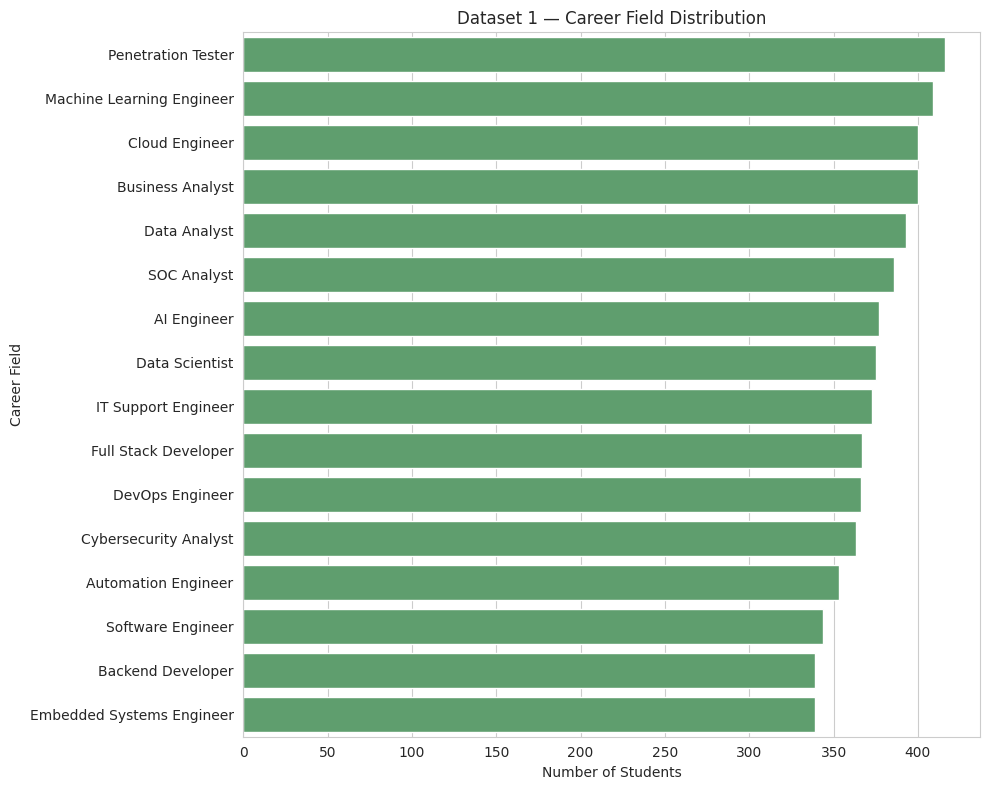

In [14]:
plt.figure(figsize=(10, 8))
sns.barplot(data=career_distribution, x="Student Count", y="Career_Field", color="#55A868")
plt.title("Dataset 1 — Career Field Distribution")
plt.xlabel("Number of Students")
plt.ylabel("Career Field")
plt.tight_layout()
plt.show()


In [15]:
num_career_classes = df1["Career_Field"].nunique()
most_common_career = career_counts.idxmax()
least_common_career = career_counts.idxmin()
imbalance_ratio = round(career_counts.max() / career_counts.min(), 2)

print(f"Number of unique career fields: {num_career_classes}")
print(f"Most common career: {most_common_career} ({career_counts.max()} students)")
print(f"Least common career: {least_common_career} ({career_counts.min()} students)")
print(f"Imbalance ratio (max/min): {imbalance_ratio}")


Number of unique career fields: 16
Most common career: Penetration Tester (416 students)
Least common career: Backend Developer (339 students)
Imbalance ratio (max/min): 1.23


**What does this result mean?**

If one career has many more records than another career, the ML model may become biased toward the
majority class. Based on the imbalance ratio above, we can judge whether the classes are **roughly
balanced** (ratio close to 1) or **imbalanced** (ratio noticeably greater than 1). We do **not**
perform any class balancing (e.g. oversampling/undersampling) in this module — that decision belongs to
Module 2/3.


## 9. Dataset 1 — Technical Skills Analysis

**What are we doing?**

Dataset 1 contains 40+ technical skill columns (prefixed `Skill_`). We first auto-detect these columns,
then inspect their actual value format instead of assuming it, and analyze how common each skill is.


In [16]:
skill_cols_1 = [c for c in df1.columns if c.startswith("Skill_")]
print(f"Number of skill columns detected: {len(skill_cols_1)}")
print(skill_cols_1)


Number of skill columns detected: 41
['Skill_AWS', 'Skill_Adobe_XD', 'Skill_Agile', 'Skill_Ansible', 'Skill_Azure', 'Skill_CI_CD', 'Skill_Cybersecurity', 'Skill_Data_Analysis', 'Skill_Django', 'Skill_Docker', 'Skill_Elasticsearch', 'Skill_FastAPI', 'Skill_Figma', 'Skill_Flutter', 'Skill_GCP', 'Skill_Git', 'Skill_GraphQL', 'Skill_JavaScript', 'Skill_Kubernetes', 'Skill_Laravel', 'Skill_Linux', 'Skill_Machine_Learning', 'Skill_MongoDB', 'Skill_MySQL', 'Skill_Networking', 'Skill_Node.js', 'Skill_NumPy', 'Skill_PHP', 'Skill_Pandas', 'Skill_PostgreSQL', 'Skill_PyTorch', 'Skill_Python', 'Skill_REST_APIs', 'Skill_React', 'Skill_React_Native', 'Skill_Redis', 'Skill_SQL', 'Skill_Scrum', 'Skill_TensorFlow', 'Skill_Terraform', 'Skill_TypeScript']


In [17]:
# Inspect the actual value format instead of assuming it
sample_skill = skill_cols_1[0]
print(f"Data type of '{sample_skill}': {df1[sample_skill].dtype}")
print(f"Unique values in '{sample_skill}': {sorted(df1[sample_skill].unique())[:15]}")


Data type of 'Skill_AWS': int64
Unique values in 'Skill_AWS': [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


In [18]:
# Check the range of values across ALL skill columns to confirm the format
all_skill_values = pd.unique(df1[skill_cols_1].values.ravel())
print("All distinct values found across every skill column:")
print(sorted(all_skill_values))


All distinct values found across every skill column:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


**What does this result mean?**

The values above tell us whether skills are stored as `0/1` flags, `Yes/No` text, `True/False` booleans,
or as a **proficiency-level integer scale** (e.g. 0 = no skill, higher numbers = stronger skill). We
detect this directly from the data rather than assuming a binary format — this matters because our later
skill-gap logic must match the real encoding.


In [19]:
missing_skills_1 = df1[skill_cols_1].isnull().sum()
print("Missing values in skill columns:")
print(missing_skills_1[missing_skills_1 > 0] if missing_skills_1.sum() > 0 else "None — no missing values in any skill column.")


Missing values in skill columns:
None — no missing values in any skill column.


In [20]:
# Treat any value greater than 0 as 'student has some level of this skill'
skill_presence = (df1[skill_cols_1] > 0).sum().sort_values(ascending=False)
skill_presence_percent = (skill_presence / len(df1) * 100).round(2)

skill_summary = pd.DataFrame({
    "Skill": skill_presence.index,
    "Students With Skill": skill_presence.values,
    "Percentage": skill_presence_percent.values
})
skill_summary.head(15)


,Skill,Students With Skill,Percentage
0,Skill_Python,5295,88.25
1,Skill_SQL,5209,86.82
2,Skill_Linux,5130,85.50
3,Skill_Git,5024,83.73
4,Skill_Networking,4952,82.53
5,Skill_Docker,4938,82.30
6,Skill_NumPy,4900,81.67
7,Skill_Pandas,4874,81.23
8,Skill_Cybersecurity,4804,80.07
9,Skill_Machine_Learning,4780,79.67


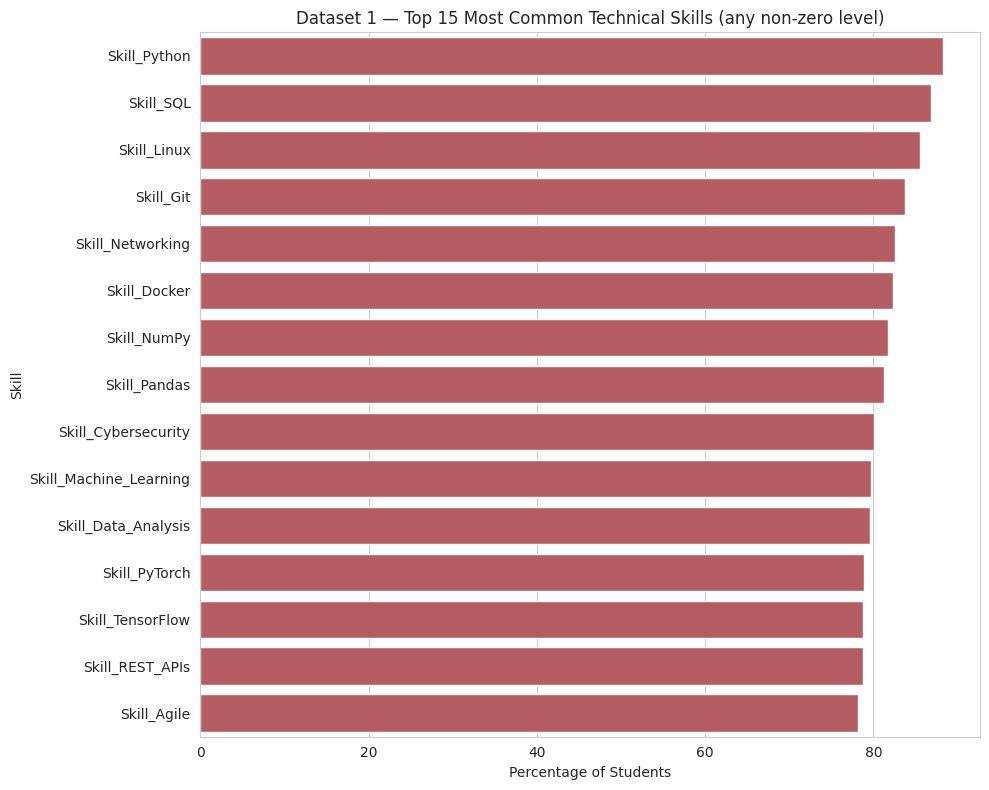

In [21]:
plt.figure(figsize=(10, 8))
top_skills = skill_summary.head(15)
sns.barplot(data=top_skills, x="Percentage", y="Skill", color="#C44E52")
plt.title("Dataset 1 — Top 15 Most Common Technical Skills (any non-zero level)")
plt.xlabel("Percentage of Students")
plt.tight_layout()
plt.show()


In [22]:
print("Least common skills:")
skill_summary.tail(10)


Least common skills:


,Skill,Students With Skill,Percentage
31,Skill_FastAPI,4515,75.25
32,Skill_Adobe_XD,4496,74.93
33,Skill_Figma,4482,74.70
34,Skill_React_Native,4475,74.58
35,Skill_GraphQL,4468,74.47
36,Skill_Flutter,4452,74.20
37,Skill_Laravel,4443,74.05
38,Skill_PHP,4437,73.95
39,Skill_Redis,4433,73.88
40,Skill_Elasticsearch,4412,73.53


**What does this result mean?**

Knowing which skills are common vs rare among students helps us understand what the student population
looks like technically. This matters for Module 2 because skill-format consistency (same scale, same
meaning across all 40+ columns) is essential before feeding these into an ML model.


## 10. Dataset 1 — Numerical Feature Analysis

**What are we doing?**

We inspect the key numerical (non-skill) features to understand their spread and to catch suspicious or
unrealistic values (e.g. CGPA out of range, attendance above 100%).


In [23]:
numeric_features_1 = ["Age", "CGPA", "Attendance_Percentage", "Study_Hours_Per_Week",
                       "Projects_Completed", "Certifications_Count", "Internships",
                       "Communication_Skills", "Teamwork", "Problem_Solving"]
numeric_features_1 = [c for c in numeric_features_1 if c in df1.columns]

num_summary_1 = df1[numeric_features_1].agg(["min", "max", "mean", "median", "std"]).T.round(2)
num_summary_1


,min,max,mean,median,std
Age,18.0,27.0,21.05,21.00,1.75
CGPA,2.0,4.0,3.10,3.11,0.39
Attendance_Percentage,47.0,100.0,81.45,81.00,9.66
Study_Hours_Per_Week,2.0,42.0,19.68,20.00,6.04
Projects_Completed,2.0,17.0,6.87,7.00,2.13
Certifications_Count,0.0,8.0,1.49,1.00,1.22
Internships,0.0,5.0,1.21,1.00,1.07
Communication_Skills,0.0,10.0,6.48,6.00,1.80
Teamwork,0.0,10.0,6.45,6.00,1.80
Problem_Solving,0.0,10.0,6.48,6.00,1.80


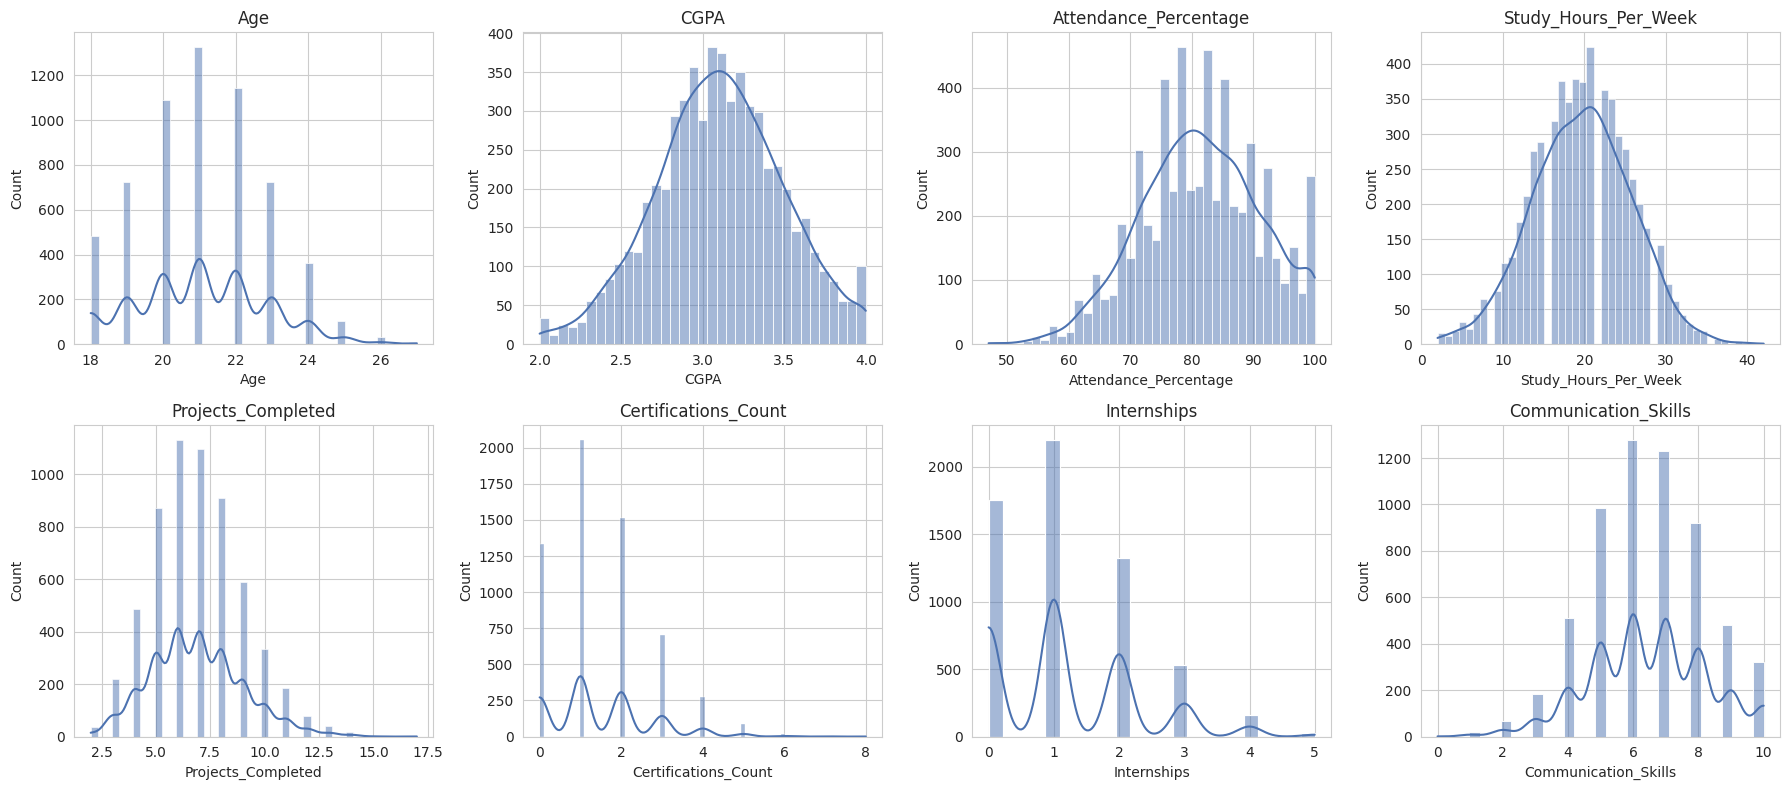

In [24]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_features_1[:8]):
    sns.histplot(df1[col], kde=True, ax=axes[i], color="#4C72B0")
    axes[i].set_title(col)
plt.tight_layout()
plt.show()


In [25]:
# Check for suspicious values
suspicious_report = {}

if "CGPA" in df1.columns:
    suspicious_report["CGPA out of 0-4 range"] = df1[(df1["CGPA"] < 0) | (df1["CGPA"] > 4)].shape[0]
if "Attendance_Percentage" in df1.columns:
    suspicious_report["Attendance above 100%"] = df1[df1["Attendance_Percentage"] > 100].shape[0]
    suspicious_report["Attendance below 0%"] = df1[df1["Attendance_Percentage"] < 0].shape[0]
if "Study_Hours_Per_Week" in df1.columns:
    suspicious_report["Negative Study Hours"] = df1[df1["Study_Hours_Per_Week"] < 0].shape[0]
if "Projects_Completed" in df1.columns:
    suspicious_report["Negative Projects Completed"] = df1[df1["Projects_Completed"] < 0].shape[0]
if "Certifications_Count" in df1.columns:
    suspicious_report["Negative Certifications"] = df1[df1["Certifications_Count"] < 0].shape[0]
if "Age" in df1.columns:
    suspicious_report["Unrealistic Age (<15 or >40)"] = df1[(df1["Age"] < 15) | (df1["Age"] > 40)].shape[0]

pd.DataFrame(list(suspicious_report.items()), columns=["Check", "Suspicious Row Count"])


,Check,Suspicious Row Count
0,CGPA out of 0-4 range,0
1,Attendance above 100%,0
2,Attendance below 0%,0
3,Negative Study Hours,0
4,Negative Projects Completed,0
5,Negative Certifications,0
6,Unrealistic Age (<15 or >40),0


**What does this result mean?**

Any non-zero count above flags a real data-quality issue we should handle in Module 2 (e.g. capping,
removing, or investigating those rows). We are only **reporting** these values here, not removing them.


## 11. Dataset 1 — Correlation Analysis

**What are we doing?**

Correlation measures how strongly two numerical features move together (from -1 to +1). This can hint
at redundant features or interesting relationships, but **correlation does not imply causation** — a
strong correlation only tells us the numbers move together, not that one causes the other.


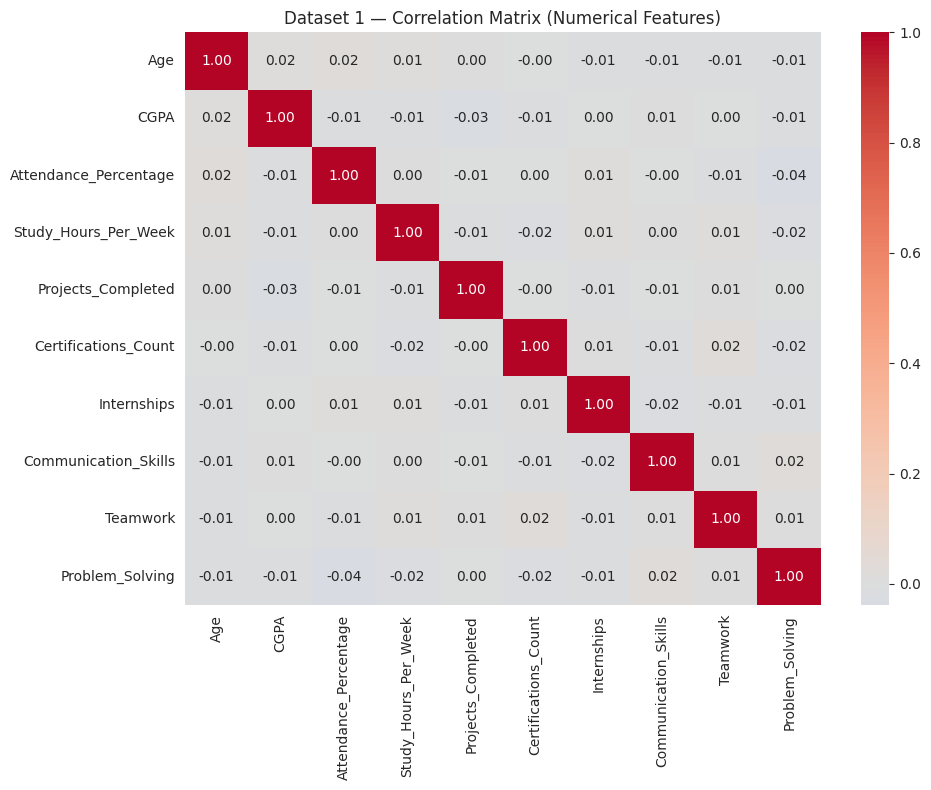

In [26]:
corr_matrix_1 = df1[numeric_features_1].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_1, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Dataset 1 — Correlation Matrix (Numerical Features)")
plt.tight_layout()
plt.show()


**What does this result mean?**

Values close to +1 or -1 indicate features that move strongly together (or oppositely). Values near 0
indicate little to no linear relationship. We keep this purely observational — no features are removed
here.


## 12. Dataset 1 — Initial EDA Findings

**What are we doing?**

We now auto-summarize what we found so far, using only the actual calculated results above.


In [27]:
d1_findings = f"""
Dataset 1 Findings
-------------------
- Dataset size: {df1.shape[0]} rows, {df1.shape[1]} columns
- Missing values: {'None found' if len(df1_missing) == 0 else f'{len(df1_missing)} column(s) have missing values'}
- Duplicate rows: {dup_count_1} ({dup_percent_1}%)
- Number of career classes: {num_career_classes}
- Class imbalance ratio (max/min): {imbalance_ratio}
- Most common career: {most_common_career}
- Least common career: {least_common_career}
- Number of technical skill columns: {len(skill_cols_1)}
- Skill value range detected: {sorted(all_skill_values)}
- Suspicious numerical values found: {sum(suspicious_report.values())} total flagged rows across all checks
"""
print(d1_findings)



Dataset 1 Findings
-------------------
- Dataset size: 6000 rows, 57 columns
- Missing values: None found
- Duplicate rows: 0 (0.0%)
- Number of career classes: 16
- Class imbalance ratio (max/min): 1.23
- Most common career: Penetration Tester
- Least common career: Backend Developer
- Number of technical skill columns: 41
- Skill value range detected: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
- Suspicious numerical values found: 0 total flagged rows across all checks



These findings will directly feed into the **Module 2 Requirements** at the end of this notebook.


## 13. Load Dataset 2 — Pakistan Job Market Dataset

**What are we doing?**

We now switch to Dataset 2 and repeat a similar audit process, independently from Dataset 1.


In [28]:
DATASET_2_PATH = "pakistan_job_market_dataset.csv"

df2 = pd.read_csv(DATASET_2_PATH)
df2.head()


,Job Title,Company,City,Sector,Salary Range (PKR),Required Skills,Experience Required,Job Type,Education Level,Gender Preference,Number of Vacancies,Posted Date,Application Deadline
0,Operations Manager,Bank Alfalah,Rawalpindi,Banking & Finance,"150,000 - 225,000","MS Excel, Loan Origination, Banking Regulation...",5+ years,Onsite,MBA,No Preference,1,4/19/2025,6/16/2025
1,Advocacy Officer,Edhi Foundation,Bahawalpur,NGO & Development,"110,000 - 185,000","M&E Frameworks, Report Writing, Stakeholder En...",5+ years,Onsite,Master's,No Preference,1,10/12/2024,12/11/2024
2,Compliance Officer,JS Bank,Peshawar,Banking & Finance,"60,000 - 105,000","Financial Analysis, MS Excel, Treasury Managem...",1-3 years,Hybrid,Master's,No Preference,3,9/21/2024,11/17/2024
3,Professor,Punjab University,Faisalabad,Education,"70,000 - 145,000","Classroom Management, Lesson Planning, Educati...",3-5 years,Onsite,Master's,No Preference,1,5/26/2024,6/16/2024
4,Demand Planner,P&G Pakistan,Karachi,FMCG & Consumer Goods,"50,000 - 75,000","Supply Chain, Nielsen, Market Research, Market...",Fresh,Remote,Bachelor's,No Preference,5,9/18/2024,10/22/2024


In [29]:
df2.shape


(10500, 13)

In [30]:
df2.info()


<class 'pandas.DataFrame'>
RangeIndex: 10500 entries, 0 to 10499
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Job Title             10500 non-null  str  
 1   Company               10500 non-null  str  
 2   City                  10500 non-null  str  
 3   Sector                10500 non-null  str  
 4   Salary Range (PKR)    10185 non-null  str  
 5   Required Skills       10500 non-null  str  
 6   Experience Required   10395 non-null  str  
 7   Job Type              10500 non-null  str  
 8   Education Level       10290 non-null  str  
 9   Gender Preference     10343 non-null  str  
 10  Number of Vacancies   10500 non-null  int64
 11  Posted Date           10500 non-null  str  
 12  Application Deadline  10500 non-null  str  
dtypes: int64(1), str(12)
memory usage: 1.0 MB


**What does this result mean?**

We now know how many job postings we have and what attributes describe each one — this will guide the
rest of the Dataset 2 audit.


## 14. Dataset 2 — Basic Audit

**What are we doing?**

We repeat the same structural checks we did for Dataset 1: shape, columns, data types, statistical
summary, missing values, duplicates, and unique values.


In [31]:
print(f"Rows: {df2.shape[0]}")
print(f"Columns: {df2.shape[1]}")
print()
print("Column names:")
print(df2.columns.tolist())


Rows: 10500
Columns: 13

Column names:
['Job Title', 'Company', 'City', 'Sector', 'Salary Range (PKR)', 'Required Skills', 'Experience Required', 'Job Type', 'Education Level', 'Gender Preference', 'Number of Vacancies', 'Posted Date', 'Application Deadline']


In [32]:
df2.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Job Title,10500,204,Product Manager,106,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Company,10500,185,Creative Chaos,105,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,10500,22,Karachi,2181,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sector,10500,13,IT & Technology,1889,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Salary Range (PKR),10185,433,"60,000 - 110,000",148,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Required Skills,10500,10470,"Google Workspace, Lesson Planning, Training De...",2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Experience Required,10395,4,1-3 years,3709,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job Type,10500,3,Onsite,6778,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education Level,10290,8,Bachelor's,5168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender Preference,10343,3,No Preference,7808,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [33]:
df2_missing = missing_value_report(df2)
df2_missing


,Column,Missing Count,Missing Percentage
0,Salary Range (PKR),315,3.0
1,Education Level,210,2.0
2,Gender Preference,157,1.5
3,Experience Required,105,1.0


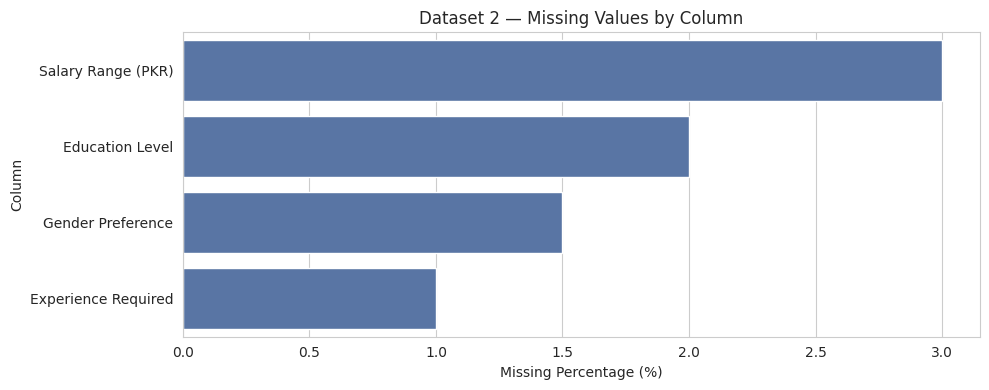

In [34]:
if len(df2_missing) > 0:
    plt.figure(figsize=(10, max(4, len(df2_missing) * 0.4)))
    sns.barplot(data=df2_missing, x="Missing Percentage", y="Column", color="#4C72B0")
    plt.title("Dataset 2 — Missing Values by Column")
    plt.xlabel("Missing Percentage (%)")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in Dataset 2.")


In [35]:
dup_count_2 = df2.duplicated().sum()
dup_percent_2 = round((dup_count_2 / len(df2)) * 100, 2)
print(f"Duplicate rows in Dataset 2: {dup_count_2}")
print(f"Duplicate percentage: {dup_percent_2}%")


Duplicate rows in Dataset 2: 0
Duplicate percentage: 0.0%


In [36]:
for col in ["City", "Sector", "Job Type", "Education Level", "Gender Preference", "Experience Required"]:
    if col in df2.columns:
        print(f"--- {col} ---")
        print(f"Unique values: {df2[col].nunique()}")
        print(df2[col].value_counts().head(10))
        print()


--- City ---
Unique values: 22


City
Karachi       2181
Lahore        1991
Islamabad     1479
Rawalpindi     759
Faisalabad     629
Peshawar       610
Multan         540
Sialkot        427
Quetta         420
Hyderabad      339
Name: count, dtype: int64

--- Sector ---
Unique values: 13
Sector
IT & Technology             1889
Banking & Finance           1130
Education                   1070
Healthcare                   939
E-commerce & Retail          811
Telecom                      713
Government & Public          700
Manufacturing                700
FMCG & Consumer Goods        616
Logistics & Supply Chain     546
Name: count, dtype: int64

--- Job Type ---
Unique values: 3
Job Type
Onsite    6778
Hybrid    1957
Remote    1765
Name: count, dtype: int64

--- Education Level ---
Unique values: 8
Education Level
Bachelor's      5168
Master's        2781
MBA              743
Intermediate     599
MBBS             348
MPhil            292
PhD              212
Matric           147
Name: count, dtype: int64

--- Gender Pre

**What does this result mean?**

This gives us a first look at how consistent and clean Dataset 2's categorical fields are, and whether
missing data or duplicates could be a problem before we go deeper into job titles and skills.


## 15. Dataset 2 — Job Title Analysis

**What are we doing?**

We analyze the `Job Title` column to understand how many distinct job titles exist, which are most
common, and whether similar titles appear as separate variants (e.g. "Data Scientist" vs
"Senior Data Scientist") that may need normalization later.


In [37]:
job_title_counts = df2["Job Title"].value_counts()
print(f"Number of unique job titles: {df2['Job Title'].nunique()}")
print()
print("Top 20 job titles:")
job_title_counts.head(20)


Number of unique job titles: 204

Top 20 job titles:


Job Title
Product Manager              106
Compliance Officer            90
Assistant Professor           90
Network Administrator         90
Cybersecurity Analyst         87
Cloud Engineer                85
Mobile App Developer          84
ERP Consultant                83
QA Engineer                   82
Software Engineer             82
Branch Manager                81
Technical Project Manager     80
Full Stack Developer          80
Trade Finance Officer         80
Investment Analyst            79
Operations Manager            78
Finance Manager               78
Machine Learning Engineer     78
Training Specialist           77
Android Developer             77
Name: count, dtype: int64

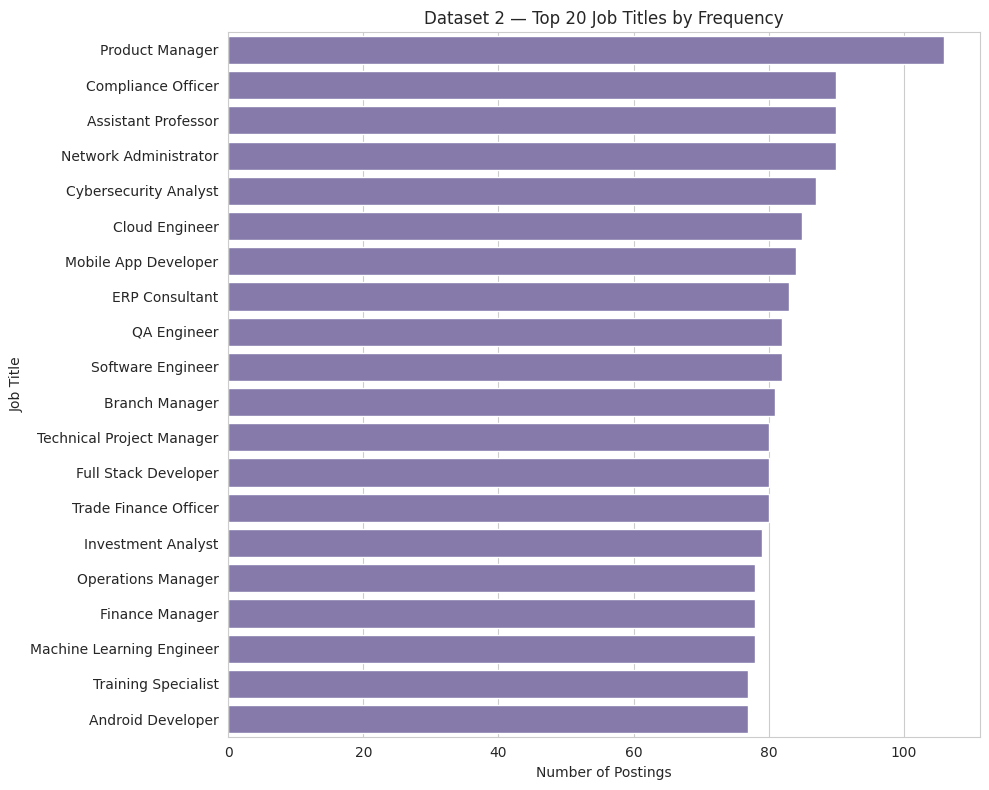

In [38]:
plt.figure(figsize=(10, 8))
top_titles = job_title_counts.head(20)
sns.barplot(x=top_titles.values, y=top_titles.index, color="#8172B2")
plt.title("Dataset 2 — Top 20 Job Titles by Frequency")
plt.xlabel("Number of Postings")
plt.tight_layout()
plt.show()


In [39]:
# Look for potential naming variations (e.g. same role with Junior/Senior/abbreviation prefixes)
all_titles = df2["Job Title"].dropna().unique()
title_words = ["Data Scientist", "Data Analyst", "Machine Learning", "ML Engineer",
               "Software Engineer", "Web Developer", "Cloud Engineer", "Cyber Security", "Cybersecurity"]

for keyword in title_words:
    matches = [t for t in all_titles if keyword.lower() in t.lower()]
    if matches:
        print(f"Variants containing '{keyword}': {matches}")


Variants containing 'Data Scientist': ['Data Scientist']
Variants containing 'Data Analyst': ['Data Analyst']
Variants containing 'Machine Learning': ['Machine Learning Engineer']
Variants containing 'Software Engineer': ['Software Engineer']
Variants containing 'Cloud Engineer': ['Cloud Engineer']
Variants containing 'Cybersecurity': ['Cybersecurity Analyst']


**What does this result mean?**

If several title variants map to essentially the same role (e.g. "ML Engineer" and
"Machine Learning Engineer"), this is a **potential normalization requirement** for Module 2 — we do
not merge them automatically here, only flag the pattern.


## 16. Dataset 2 — Required Skills Analysis

**What are we doing?**

We inspect the raw format of the `Required Skills` column: how skills are separated, how many skills
are listed per job, and whether the same skill appears with inconsistent spelling/casing.


In [40]:
print("Raw examples of the 'Required Skills' column:")
for val in df2["Required Skills"].dropna().head(5):
    print("-", val)


Raw examples of the 'Required Skills' column:
- MS Excel, Loan Origination, Banking Regulations, KYC, Forecasting, SBP Compliance, Credit Appraisal
- M&E Frameworks, Report Writing, Stakeholder Engagement, Community Mobilization, Project Management, SPSS, Data Collection Tools
- Financial Analysis, MS Excel, Treasury Management, IFRS, Financial Modeling, Temenos
- Classroom Management, Lesson Planning, Educational Psychology, MATLAB
- Supply Chain, Nielsen, Market Research, Marketing Analytics, Trade Marketing, Power BI, Sales Strategy


In [41]:
# Detect the separator used
sample_values = df2["Required Skills"].dropna().head(200)
separator_counts = {
    ",": sample_values.str.contains(",").sum(),
    ";": sample_values.str.contains(";").sum(),
    "|": sample_values.str.contains(r"\|", regex=True).sum(),
    "/": sample_values.str.contains("/").sum(),
}
print("Separator occurrence counts (out of 200 sampled rows):")
for sep, cnt in separator_counts.items():
    print(f"  '{sep}': {cnt}")


Separator occurrence counts (out of 200 sampled rows):
  ',': 200
  ';': 0
  '|': 0
  '/': 13


In [42]:
# Based on detected separator, split into individual skills
SKILL_SEPARATOR = ","  # detected from the check above

skills_missing_2 = df2["Required Skills"].isnull().sum()
print(f"Missing 'Required Skills' values: {skills_missing_2} ({round(skills_missing_2/len(df2)*100, 2)}%)")

exploded_skills = (
    df2["Required Skills"].dropna()
    .str.split(SKILL_SEPARATOR)
    .explode()
    .str.strip()
)

print(f"Total individual skill mentions: {len(exploded_skills)}")
print(f"Number of DISTINCT raw skill strings: {exploded_skills.nunique()}")


Missing 'Required Skills' values: 0 (0.0%)
Total individual skill mentions: 57597
Number of DISTINCT raw skill strings: 210


In [43]:
skills_per_job = df2["Required Skills"].dropna().str.split(SKILL_SEPARATOR).apply(len)
print("Skills required per job — summary:")
print(skills_per_job.describe().round(2))


Skills required per job — summary:
count    10500.00
mean         5.49
std          1.72
min          3.00
25%          4.00
50%          5.00
75%          7.00
max          8.00
Name: Required Skills, dtype: float64


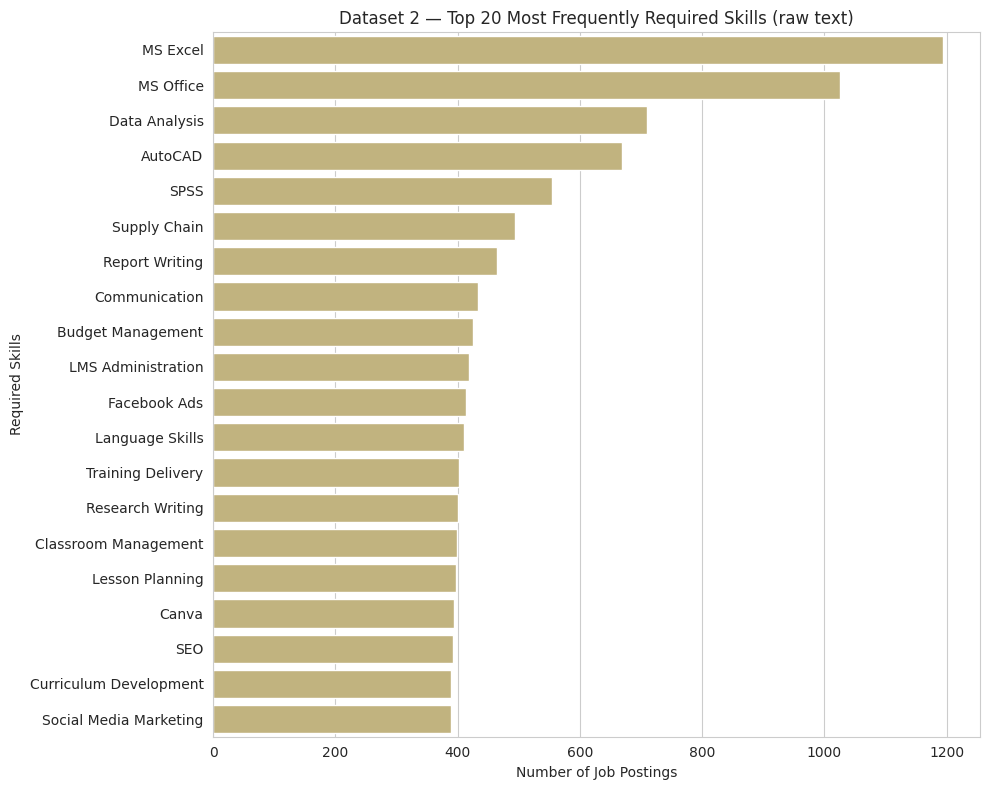

In [44]:
top_required_skills = exploded_skills.value_counts().head(20)
plt.figure(figsize=(10, 8))
sns.barplot(x=top_required_skills.values, y=top_required_skills.index, color="#CCB974")
plt.title("Dataset 2 — Top 20 Most Frequently Required Skills (raw text)")
plt.xlabel("Number of Job Postings")
plt.tight_layout()
plt.show()


In [45]:
# Check for near-duplicate skill spellings using a normalized (lowercase, no punctuation) version
normalized_skills = exploded_skills.str.lower().str.replace(r"[^a-z0-9\s]", "", regex=True).str.strip()
raw_to_normalized = pd.DataFrame({"raw": exploded_skills.values, "normalized": normalized_skills.values})

# Find normalized skills that map back to MORE THAN ONE raw spelling -> possible inconsistency
variants = raw_to_normalized.groupby("normalized")["raw"].nunique().sort_values(ascending=False)
inconsistent_skills = variants[variants > 1]
print(f"Number of normalized skill terms with multiple raw spellings: {len(inconsistent_skills)}")
inconsistent_skills.head(15)


Number of normalized skill terms with multiple raw spellings: 0


Series([], Name: raw, dtype: int64)

**What does this result mean?**

If several raw skill strings collapse into a single normalized term (e.g. "Python" vs "python" vs
"Python Programming"), that indicates real inconsistency in how skills were entered. We flag this as a
normalization requirement rather than fixing it here.


## 17. Dataset 2 — Location Analysis

**What are we doing?**

Since SkillBridge targets the Pakistani job market, understanding the geographic distribution of job
postings is important context.


In [46]:
city_counts = df2["City"].value_counts()
print(f"Number of unique cities: {df2['City'].nunique()}")
city_counts.head(15)


Number of unique cities: 22


City
Karachi       2181
Lahore        1991
Islamabad     1479
Rawalpindi     759
Faisalabad     629
Peshawar       610
Multan         540
Sialkot        427
Quetta         420
Hyderabad      339
Gujranwala     283
Abbottabad     215
Bahawalpur     205
Sukkur         127
Karachì         46
Name: count, dtype: int64

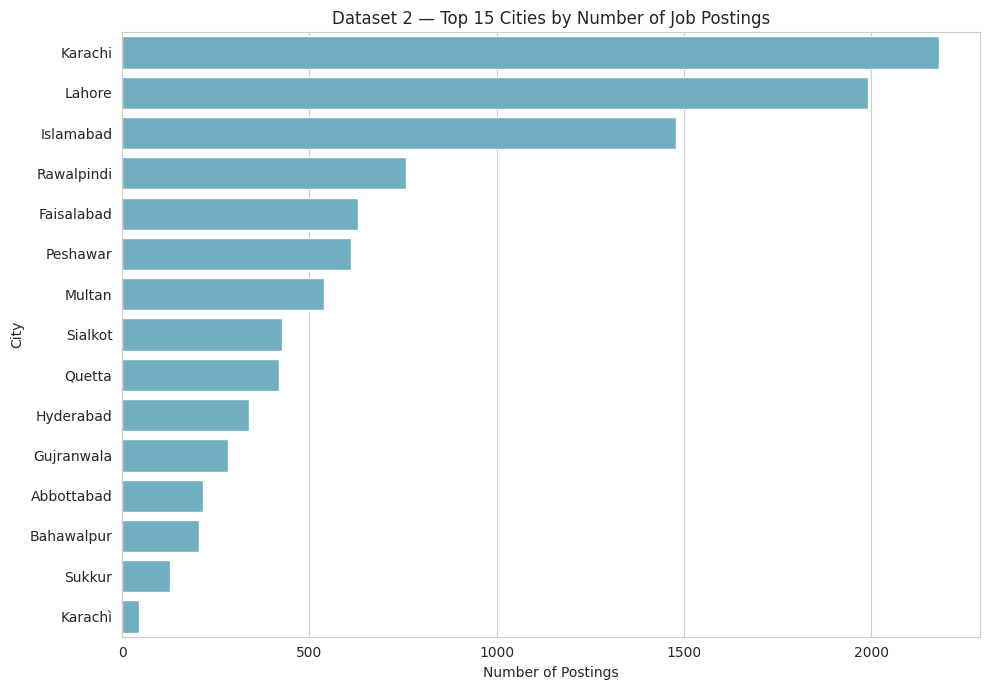

In [47]:
plt.figure(figsize=(10, 7))
top_cities = city_counts.head(15)
sns.barplot(x=top_cities.values, y=top_cities.index, color="#64B5CD")
plt.title("Dataset 2 — Top 15 Cities by Number of Job Postings")
plt.xlabel("Number of Postings")
plt.tight_layout()
plt.show()


**What does this result mean?**

This shows us which cities dominate the job market data. If job matching results are heavily
concentrated in a few cities, that is useful context for interpreting recommendations later.


## 18. Dataset 2 — Sector Analysis

**What are we doing?**

We look at the `Sector` and `Job Type` columns to understand what kinds of industries and employment
types are represented.


Number of unique sectors: 13


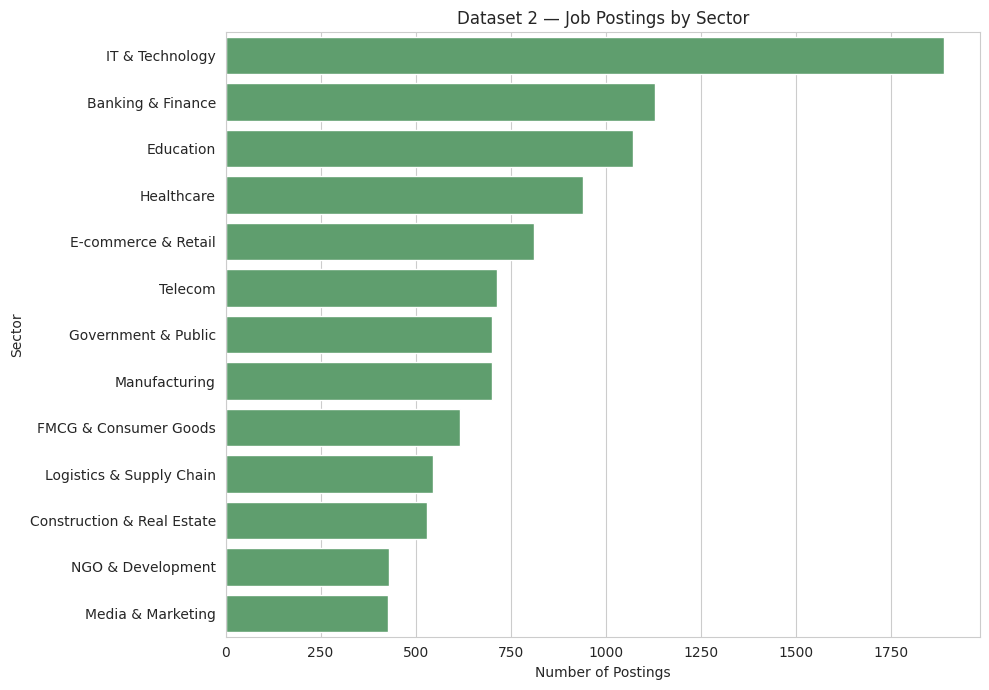

In [48]:
sector_counts = df2["Sector"].value_counts()
print(f"Number of unique sectors: {df2['Sector'].nunique()}")

plt.figure(figsize=(10, 7))
sns.barplot(x=sector_counts.values, y=sector_counts.index, color="#55A868")
plt.title("Dataset 2 — Job Postings by Sector")
plt.xlabel("Number of Postings")
plt.tight_layout()
plt.show()


In [49]:
if "Job Type" in df2.columns:
    print("Job Type distribution:")
    print(df2["Job Type"].value_counts())


Job Type distribution:
Job Type
Onsite    6778
Hybrid    1957
Remote    1765
Name: count, dtype: int64


**What does this result mean?**

The sector distribution tells us which industries are best represented in the job data — this matters
because career fields from Dataset 1 (e.g. AI, Cybersecurity) need to be matched against sectors and
titles that actually exist here in meaningful volume.


## 19. Dataset 2 — Salary Analysis

**What are we doing?**

We inspect the salary column's format and completeness. We only **identify** issues here — no cleaning
or parsing into numeric values happens in this module.


In [50]:
salary_col = "Salary Range (PKR)"

print(f"Data type: {df2[salary_col].dtype}")
missing_salary = df2[salary_col].isnull().sum()
print(f"Missing salary values: {missing_salary} ({round(missing_salary/len(df2)*100, 2)}%)")
print()
print("Raw examples:")
for val in df2[salary_col].dropna().head(10):
    print("-", val)


Data type: str
Missing salary values: 315 (3.0%)

Raw examples:
- 150,000 - 225,000
- 110,000 - 185,000
- 60,000 - 105,000
- 70,000 - 145,000
- 50,000 - 75,000
- 50,000 - 75,000
- 50,000 - 120,000
- 60,000 - 110,000
- 90,000 - 145,000
- 110,000 - 165,000


In [51]:
# Identify the format pattern without converting yet
sample = df2[salary_col].dropna().astype(str)
has_range = sample.str.contains("-").mean() * 100
has_comma = sample.str.contains(",").mean() * 100
has_currency_word = sample.str.contains("PKR|Rs", case=False, regex=True).mean() * 100
has_k_suffix = sample.str.contains("K", case=False).mean() * 100

print(f"Percentage of values containing a range ('-'): {round(has_range, 2)}%")
print(f"Percentage of values containing comma-formatted numbers: {round(has_comma, 2)}%")
print(f"Percentage of values containing a currency word (PKR/Rs): {round(has_currency_word, 2)}%")
print(f"Percentage of values containing a 'K' suffix (e.g. 50K): {round(has_k_suffix, 2)}%")


Percentage of values containing a range ('-'): 100.0%
Percentage of values containing comma-formatted numbers: 100.0%
Percentage of values containing a currency word (PKR/Rs): 0.0%
Percentage of values containing a 'K' suffix (e.g. 50K): 0.0%


**What does this result mean?**

The salary column is stored as a **text range** (e.g. `"150,000 - 225,000"`), not as a clean numeric
value. Before any salary-based analysis or filtering can be done in later modules, this column will need
to be parsed into numeric minimum/maximum salary fields — this is a clear **Module 2 requirement**, not
something we fix here.


## 20. Dataset 2 — Experience & Education Analysis

**What are we doing?**

We inspect the `Experience Required` and `Education Level` columns for consistency and completeness.


In [52]:
for col in ["Experience Required", "Education Level"]:
    if col in df2.columns:
        print(f"--- {col} ---")
        print(f"Unique values: {df2[col].nunique()}")
        print(f"Missing values: {df2[col].isnull().sum()}")
        print(df2[col].value_counts())
        print()


--- Experience Required ---
Unique values: 4
Missing values: 105
Experience Required
1-3 years    3709
3-5 years    2877
Fresh        2094
5+ years     1715
Name: count, dtype: int64

--- Education Level ---
Unique values: 8
Missing values: 210
Education Level
Bachelor's      5168
Master's        2781
MBA              743
Intermediate     599
MBBS             348
MPhil            292
PhD              212
Matric           147
Name: count, dtype: int64



**What does this result mean?**

We note the actual categories used (e.g. "5+ years", "MBA", "Master's") so that later modules know
exactly what format to expect when matching a student's profile (years of experience, degree level)
against job requirements.


## 21. Dataset 2 — Initial EDA Findings

**What are we doing?**

We summarize what we found about Dataset 2, using only the actual calculated results above.


In [53]:
d2_findings = f"""
Dataset 2 Findings
-------------------
- Dataset size: {df2.shape[0]} rows, {df2.shape[1]} columns
- Missing values: {'None found' if len(df2_missing) == 0 else f'{len(df2_missing)} column(s) have missing values'}
- Duplicate rows: {dup_count_2} ({dup_percent_2}%)
- Unique job titles: {df2['Job Title'].nunique()}
- Most common job title: {job_title_counts.idxmax()} ({job_title_counts.max()} postings)
- Unique cities: {df2['City'].nunique()}
- Unique sectors: {df2['Sector'].nunique()}
- Required Skills separator detected: '{SKILL_SEPARATOR}'
- Distinct raw skill strings in 'Required Skills': {exploded_skills.nunique()}
- Skill strings with inconsistent spelling variants: {len(inconsistent_skills)}
- Salary column format: text range (e.g. "150,000 - 225,000"), needs numeric parsing
"""
print(d2_findings)



Dataset 2 Findings
-------------------
- Dataset size: 10500 rows, 13 columns
- Missing values: 4 column(s) have missing values
- Duplicate rows: 0 (0.0%)
- Unique job titles: 204
- Most common job title: Product Manager (106 postings)
- Unique cities: 22
- Unique sectors: 13
- Required Skills separator detected: ','
- Distinct raw skill strings in 'Required Skills': 210
- Skill strings with inconsistent spelling variants: 0
- Salary column format: text range (e.g. "150,000 - 225,000"), needs numeric parsing



## 22. Dataset Compatibility Analysis

**What are we doing?**

This is the most important section of Module 1. We check whether Dataset 1's `Career_Field` values can
reasonably be connected to Dataset 2's `Job Title` values, using a simple, temporary, exploratory text
comparison. We do **not** permanently modify either dataset, and we do **not** force a match where none
exists.


In [54]:
def normalize_text(text):
    text = str(text).lower().strip()
    text = re.sub(r"[^a-z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text

career_fields = sorted(df1["Career_Field"].unique())
print(f"All {len(career_fields)} unique Career_Field values in Dataset 1:")
for c in career_fields:
    print(" -", c)


All 16 unique Career_Field values in Dataset 1:
 - AI Engineer
 - Automation Engineer
 - Backend Developer
 - Business Analyst
 - Cloud Engineer
 - Cybersecurity Analyst
 - Data Analyst
 - Data Scientist
 - DevOps Engineer
 - Embedded Systems Engineer
 - Full Stack Developer
 - IT Support Engineer
 - Machine Learning Engineer
 - Penetration Tester
 - SOC Analyst
 - Software Engineer


In [55]:
unique_job_titles = df2["Job Title"].unique()
print(f"Dataset 2 has {len(unique_job_titles)} unique job titles. Top 25 most frequent:")
job_title_counts.head(25)


Dataset 2 has 204 unique job titles. Top 25 most frequent:


Job Title
Product Manager              106
Compliance Officer            90
Assistant Professor           90
Network Administrator         90
Cybersecurity Analyst         87
Cloud Engineer                85
Mobile App Developer          84
ERP Consultant                83
QA Engineer                   82
Software Engineer             82
Branch Manager                81
Technical Project Manager     80
Full Stack Developer          80
Trade Finance Officer         80
Investment Analyst            79
Operations Manager            78
Finance Manager               78
Machine Learning Engineer     78
Training Specialist           77
Android Developer             77
AI Engineer                   77
Data Analyst                  77
System Administrator          77
Curriculum Developer          76
School Principal              76
Name: count, dtype: int64

In [56]:
# Temporary normalized copies for comparison ONLY (originals untouched)
career_norm = {c: normalize_text(c) for c in career_fields}
title_norm = {t: normalize_text(t) for t in unique_job_titles}

# For each Career_Field, find job titles that contain it (or vice versa) as a substring match
matches = {}
for career, cnorm in career_norm.items():
    found = [title for title, tnorm in title_norm.items()
             if cnorm in tnorm or tnorm in cnorm]
    matches[career] = found

for career, found in matches.items():
    print(f"{career}  ->  {found if found else 'NO DIRECT MATCH'}")


AI Engineer  ->  ['AI Engineer']
Automation Engineer  ->  NO DIRECT MATCH
Backend Developer  ->  ['Backend Developer']
Business Analyst  ->  ['Business Analyst']
Cloud Engineer  ->  ['Cloud Engineer']
Cybersecurity Analyst  ->  ['Cybersecurity Analyst']
Data Analyst  ->  ['Data Analyst']
Data Scientist  ->  ['Data Scientist']
DevOps Engineer  ->  ['DevOps Engineer']
Embedded Systems Engineer  ->  NO DIRECT MATCH
Full Stack Developer  ->  ['Full Stack Developer']
IT Support Engineer  ->  NO DIRECT MATCH
Machine Learning Engineer  ->  ['Machine Learning Engineer']
Penetration Tester  ->  NO DIRECT MATCH
SOC Analyst  ->  NO DIRECT MATCH
Software Engineer  ->  ['Software Engineer']


**What does this result mean?**

Some `Career_Field` values (e.g. "Machine Learning Engineer", "Cloud Engineer") match job titles in
Dataset 2 almost exactly. Others are broader categories (e.g. "Business Analyst") or use different
terminology than what employers post, and do not match directly. This confirms we cannot assume a
one-to-one relationship between the two datasets.


## 23. Career Mapping Gap Analysis

**What are we doing?**

We turn the matches found above into a structured confidence table: Strong, Moderate, Weak, or No
obvious match.


In [57]:
def classify_confidence(career, found_titles):
    if not found_titles:
        return "No obvious match", "No job titles in Dataset 2 contain/relate to this career text."
    cnorm = normalize_text(career)
    exact = [t for t in found_titles if normalize_text(t) == cnorm]
    if exact:
        return "Strong", f"Exact normalized match with job title(s): {exact}"
    close = [t for t in found_titles if cnorm in normalize_text(t)]
    if close:
        return "Moderate", f"Career text appears within job title(s): {close}"
    return "Weak", f"Only partial/substring overlap found: {found_titles}"

rows = []
for career, found in matches.items():
    confidence, note = classify_confidence(career, found)
    rows.append({
        "Career_Field": career,
        "Related Job Titles Found": ", ".join(found) if found else "-",
        "Mapping Confidence": confidence,
        "Notes": note
    })

mapping_gap_table = pd.DataFrame(rows)
mapping_gap_table


,Career_Field,Related Job Titles Found,Mapping Confidence,Notes
0,AI Engineer,AI Engineer,Strong,Exact normalized match with job title(s): ['AI...
1,Automation Engineer,-,No obvious match,No job titles in Dataset 2 contain/relate to t...
2,Backend Developer,Backend Developer,Strong,Exact normalized match with job title(s): ['Ba...
3,Business Analyst,Business Analyst,Strong,Exact normalized match with job title(s): ['Bu...
4,Cloud Engineer,Cloud Engineer,Strong,Exact normalized match with job title(s): ['Cl...
5,Cybersecurity Analyst,Cybersecurity Analyst,Strong,Exact normalized match with job title(s): ['Cy...
6,Data Analyst,Data Analyst,Strong,Exact normalized match with job title(s): ['Da...
7,Data Scientist,Data Scientist,Strong,Exact normalized match with job title(s): ['Da...
8,DevOps Engineer,DevOps Engineer,Strong,Exact normalized match with job title(s): ['De...
9,Embedded Systems Engineer,-,No obvious match,No job titles in Dataset 2 contain/relate to t...


In [58]:
confidence_summary = mapping_gap_table["Mapping Confidence"].value_counts()
print("Mapping confidence summary:")
print(confidence_summary)


Mapping confidence summary:
Mapping Confidence
Strong              11
No obvious match     5
Name: count, dtype: int64


**What does this result mean?**

If a meaningful portion of career fields fall under **Weak** or **No obvious match**, it confirms:

> Dataset 1 contains broader career categories while Dataset 2 contains specific job titles. Therefore,
> a Career Mapping Layer is required.

This mapping layer (built in Module 2) will define, for each `Career_Field`, which real job titles in
Dataset 2 should be considered relevant — using domain knowledge, not just text matching.


## 24. Skill Compatibility Analysis

**What are we doing?**

We compare the technical skills tracked in Dataset 1 (the `Skill_*` columns) against the skills
mentioned in Dataset 2's `Required Skills` text, to see how much overlap exists.


In [59]:
# Clean Dataset 1 skill names (remove 'Skill_' prefix, replace underscores with spaces)
d1_skill_names = [s.replace("Skill_", "").replace("_", " ").strip() for s in skill_cols_1]
d1_skill_names_norm = set(normalize_text(s) for s in d1_skill_names)

d2_skill_names_norm = set(normalized_skills.unique())

overlap = d1_skill_names_norm & d2_skill_names_norm
only_in_d1 = d1_skill_names_norm - d2_skill_names_norm
only_in_d2 = d2_skill_names_norm - d1_skill_names_norm

print(f"Dataset 1 distinct skill names: {len(d1_skill_names_norm)}")
print(f"Dataset 2 distinct required-skill terms: {len(d2_skill_names_norm)}")
print(f"Directly overlapping (exact normalized match): {len(overlap)}")
print()
print("Overlapping skills:")
print(sorted(overlap))


Dataset 1 distinct skill names: 41
Dataset 2 distinct required-skill terms: 210
Directly overlapping (exact normalized match): 40

Overlapping skills:
['adobe xd', 'agile', 'ansible', 'aws', 'azure', 'cybersecurity', 'data analysis', 'django', 'docker', 'elasticsearch', 'fastapi', 'figma', 'flutter', 'gcp', 'git', 'graphql', 'javascript', 'kubernetes', 'laravel', 'linux', 'machine learning', 'mongodb', 'mysql', 'networking', 'nodejs', 'numpy', 'pandas', 'php', 'postgresql', 'python', 'pytorch', 'react', 'react native', 'redis', 'rest apis', 'scrum', 'sql', 'tensorflow', 'terraform', 'typescript']


In [60]:
print(f"Dataset 1 skills with NO exact match in Dataset 2 ({len(only_in_d1)}):")
print(sorted(only_in_d1))


Dataset 1 skills with NO exact match in Dataset 2 (1):
['ci cd']


In [61]:
print(f"Sample of Dataset 2 required-skill terms with NO exact match in Dataset 1 (showing top 20 by frequency):")
d2_freq_norm = normalized_skills.value_counts()
only_in_d2_sorted = [s for s in d2_freq_norm.index if s in only_in_d2]
print(only_in_d2_sorted[:20])


Sample of Dataset 2 required-skill terms with NO exact match in Dataset 1 (showing top 20 by frequency):
['ms excel', 'ms office', 'autocad', 'spss', 'supply chain', 'report writing', 'communication', 'budget management', 'lms administration', 'facebook ads', 'language skills', 'training delivery', 'research writing', 'classroom management', 'lesson planning', 'canva', 'seo', 'curriculum development', 'social media marketing', 'google workspace']


In [62]:
skill_compat_summary = pd.DataFrame({
    "Category": ["Overlapping skills", "Dataset 1 only", "Dataset 2 only"],
    "Count": [len(overlap), len(only_in_d1), len(only_in_d2)]
})
skill_compat_summary


,Category,Count
0,Overlapping skills,40
1,Dataset 1 only,1
2,Dataset 2 only,170


**What does this result mean?**

- **Overlapping skills** can be used directly for skill-gap matching.
- **Dataset 1 only** skills are tracked for students but rarely/never mentioned verbatim in job posts —
  they may exist in job posts under different phrasing (a normalization opportunity), or may simply not
  be in-demand skills in this job dataset.
- **Dataset 2 only** skills are required by employers but not tracked as a formal skill column for
  students — these represent a **gap in Dataset 1's skill coverage** that Module 2 should consider
  when designing the skill-gap analysis logic.

Given the exact-match approach used here, skill name inconsistencies (casing, phrasing, abbreviations)
mean the **true overlap is likely higher** than what a strict text match finds. This confirms that
**skill-name normalization is required** before building the final skill-gap module.


## 25. Final Module 1 Report

### Dataset 1

- **What we learned:** Dataset 1 contains student academic, behavioral, and technical-skill data
  along with a `Career_Field` target label suitable for a future classification model.
- **Data quality:** See the missing-value and duplicate results in Sections 5–6 above.
- **Target variable quality:** `Career_Field` has multiple classes with the imbalance ratio calculated
  in Section 8 — this must be considered when training/evaluating a model.
- **Skill data quality:** Skill columns use a consistent numeric scale (detected in Section 9), which is
  a good foundation, but the meaning of the scale (e.g. proficiency level vs binary flag) should be
  documented clearly before modeling.
- **ML preparation requirements:** Handle any missing values, verify duplicate `Student_ID`s, and review
  flagged suspicious numerical values before training.

### Dataset 2

- **What we learned:** Dataset 2 contains real Pakistani job postings with company, city, sector,
  salary, and required-skills information.
- **Job market data quality:** See missing-value and duplicate results in Section 14.
- **Required skills quality:** Skills are stored as delimited text (Section 16) with a detected separator
  and a measurable number of possible spelling/casing inconsistencies.
- **Job title quality:** Job titles are diverse (Section 15); some roles appear under multiple
  similarly-named variants.
- **Cleaning requirements:** Parse the salary range into numeric fields, split and normalize required
  skills, and standardize job-title variants where justified.

### Compatibility

1. **Can Dataset 1 and Dataset 2 be directly connected?** Only partially — some `Career_Field` values
   match job titles closely (see Section 22–23), while others do not match directly at all.
2. **Which career fields have strong job-title matches?** See rows marked **Strong** or **Moderate** in
   the Section 23 mapping table.
3. **Which career fields need mapping?** See rows marked **Weak** or **No obvious match** in the same
   table.
4. **Are technical skills compatible?** Partially — see the overlap counts in Section 24. Exact-text
   matching underestimates true overlap due to naming inconsistencies.
5. **What normalization is required?** Job-title normalization, required-skills text normalization
   (casing/spelling/synonyms), and salary text-to-numeric parsing.

### Module 2 Requirements

1. Handle missing values (where present)
2. Remove/handle duplicates (where present)
3. Normalize categorical values (Gender, Major, Interest_Domain, Job Type, Sector, etc.)
4. Normalize technical skills (Dataset 1 scale, Dataset 2 text-based skill names)
5. Clean numerical features (fix/flag suspicious CGPA, Attendance, Age values)
6. Handle outliers where appropriate
7. Encode categorical variables for modeling
8. Prepare `Career_Field` as the ML target (check imbalance handling strategy)
9. Create a **Career Mapping Layer** connecting `Career_Field` to relevant Dataset 2 job titles
10. Normalize Dataset 2 `Required Skills` into a clean, consistent skill list
11. Parse the `Salary Range (PKR)` column into numeric minimum/maximum salary fields
12. Prepare both datasets for ML training and career/job matching


## Module 1 Status Summary

The cell below prints a final, code-generated summary using only values calculated in this notebook —
nothing here is hardcoded or invented.


In [63]:
d1_main_issues = []
if len(df1_missing) > 0:
    d1_main_issues.append("missing values present")
if dup_count_1 > 0:
    d1_main_issues.append("duplicate rows present")
if imbalance_ratio > 2:
    d1_main_issues.append("Career_Field class imbalance")
if sum(suspicious_report.values()) > 0:
    d1_main_issues.append("suspicious numerical values present")
d1_main_issues_str = ", ".join(d1_main_issues) if d1_main_issues else "No major issues detected"

d2_main_issues = []
if len(df2_missing) > 0:
    d2_main_issues.append("missing values present")
if dup_count_2 > 0:
    d2_main_issues.append("duplicate rows present")
if len(inconsistent_skills) > 0:
    d2_main_issues.append("inconsistent skill spellings in Required Skills")
d2_main_issues.append("salary stored as text range, needs parsing")
d2_main_issues_str = ", ".join(d2_main_issues)

n_strong_moderate = confidence_summary.get("Strong", 0) + confidence_summary.get("Moderate", 0)
n_weak_none = confidence_summary.get("Weak", 0) + confidence_summary.get("No obvious match", 0)

if n_weak_none == 0:
    direct_mapping = "Yes"
elif n_strong_moderate == 0:
    direct_mapping = "No"
else:
    direct_mapping = "Partial"

career_mapping_required = "Yes" if n_weak_none > 0 else "No"
skill_normalization_required = "Yes" if len(inconsistent_skills) > 0 or len(only_in_d1) > 0 or len(only_in_d2) > 0 else "No"

summary = f"""
Module 1 Status: COMPLETED

Dataset 1:
- Rows: {df1.shape[0]}
- Columns: {df1.shape[1]}
- Career Classes: {num_career_classes}
- Missing Values: {int(df1_missing['Missing Count'].sum()) if len(df1_missing) > 0 else 0}
- Duplicates: {dup_count_1}
- Main Issues: {d1_main_issues_str}

Dataset 2:
- Rows: {df2.shape[0]}
- Columns: {df2.shape[1]}
- Job Titles: {df2['Job Title'].nunique()}
- Missing Values: {int(df2_missing['Missing Count'].sum()) if len(df2_missing) > 0 else 0}
- Duplicates: {dup_count_2}
- Main Issues: {d2_main_issues_str}

Compatibility:
- Direct Mapping: {direct_mapping}
- Career Mapping Layer Required: {career_mapping_required}
- Skill Normalization Required: {skill_normalization_required}

Next Module:
Module 2 — Data Preprocessing & Feature Engineering
"""
print(summary)



Module 1 Status: COMPLETED

Dataset 1:
- Rows: 6000
- Columns: 57
- Career Classes: 16
- Missing Values: 0
- Duplicates: 0
- Main Issues: No major issues detected

Dataset 2:
- Rows: 10500
- Columns: 13
- Job Titles: 204
- Missing Values: 787
- Duplicates: 0
- Main Issues: missing values present, salary stored as text range, needs parsing

Compatibility:
- Direct Mapping: Partial
- Career Mapping Layer Required: Yes
- Skill Normalization Required: Yes

Next Module:
Module 2 — Data Preprocessing & Feature Engineering

